<a href="https://colab.research.google.com/github/chookaiwen-1053/Assignment-5/blob/main/Programming_assignment_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

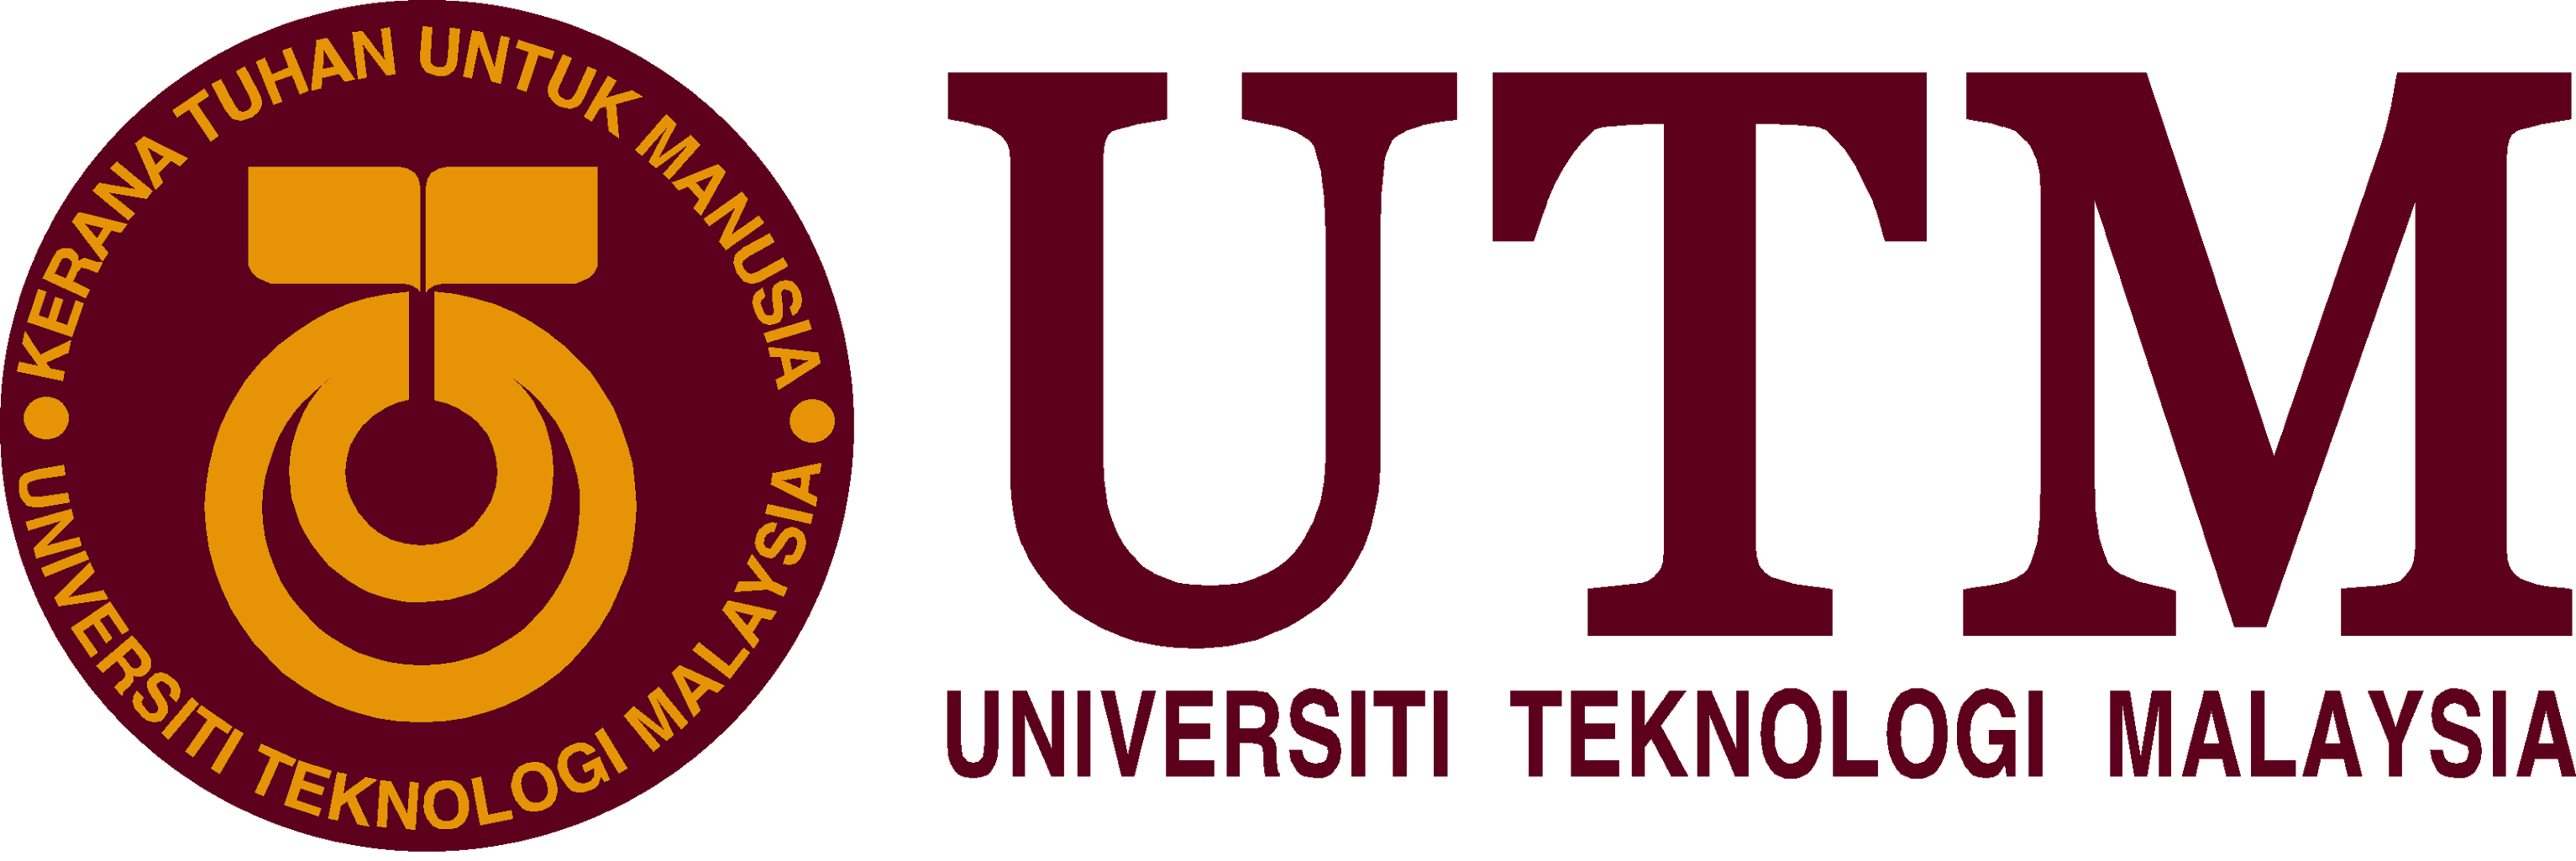

<h1>
<center>
DEPARTMENT OF ENGINEERING (ELECTRICAL-MECHATRONICS) <br>
FACULTY OF ELECTRICAL ENGINEERING <br>
UNIVERSITI TEKNOLOGI MALAYSIA
</center>
</h1>

---
<h2>
<center>
SKEE1033 - 17 SCIENTIFIC PROGRAMMING
<br> ASSIGNMENT
</center>
<h2>

---

TITLE :ELECTRICITY CONSUMPTION AND COST ANALYSIS

PREPARED BY : GROUP CURIOUS CAPYBARA

| NAME | MATRIC NO. |
| :--- | :----: |
| CHOO KAI WEN | A25KE5097 |
| KUAN JIA CHENG | A25KE5037 |
| BOO KAI CHENG |A25KE5092 |
| MUHAMMAD HARIZ SYUKRI BIN HASDI | A25KE0306 |
| PHANG ZHENG QIAN | A25KE5011 |

PREPARED FOR: DR MUHAMMAD MUN'IM AHMAD ZABIDI

##**LIST OF CONTENT**

| No |      Tittle  |
| :--- | ----: |
| 1. |    Introduction  |
| 2. | Objective  |
| 3. | Code and Result  |
| 4. | Work Division |
| 5. | Conclusion  |

##**INTRODUCTION**

The SKEE1033 2025/2026-1 Group Assignment is centered on a comprehensive Electricity Consumption and Cost Analysis. In the modern era, understanding energy dynamics is crucial for both economic stability and environmental sustainability. This report investigates a specialized dataset that records monthly household electricity consumption, associated costs, and the number of occupants living within a household. The data represents three distinct geographical classifications: Urban, Suburban, and Rural regions, providing a diverse look at how living environments affect energy needs. The records span a five-year period from 2018 to 2022, allowing for a longitudinal study of usage trends over time.


The primary motivation behind this study is to leverage Python’s computational power to transform raw data into actionable insights. By utilizing libraries such as pandas and numpy, we can clean and refine data that might otherwise be skewed by missing values or outliers. Furthermore, the inclusion of the "Occupants" variable serves as a critical real-life factor in this analysis. It allows us to understand how household size directly influences consumption levels and provides a basis for more accurate predictive modeling.


Ultimately, this report serves as a bridge between theoretical data science and practical application. By the end of this analysis, we aim to not only describe how electricity was used in the past but also to provide a reliable framework for forecasting future costs. This predictive capability is vital for households and policymakers to manage resources and anticipate financial requirements based on varying occupancy and usage levels.


##**OBJECTIVE**

The fundamental objective of this project is to perform a rigorous analysis of electricity consumption and cost using Python. A primary goal is the execution of a thorough data cleaning process, which ensures the integrity of the analysis. This involves inspecting the dataset for missing values and outliers, followed by the application of statistical methods such as interpolation or the Interquartile Range (IQR) to normalize the data. Ensuring that the dataset is clean is a prerequisite for any meaningful statistical inference or predictive accuracy.


Another key objective is to perform descriptive and comparative analysis across different household types. The study seeks to compute summary statistics specifically the mean, median, and standard deviation to quantify consumption patterns in Urban, Suburban, and Rural areas. By comparing these regions, we can determine how infrastructure and lifestyle differences impact electricity demand. Additionally, the project aims to evaluate the correlation between the number of occupants and electricity consumption to verify if household size is a statistically significant driver of energy cost.


Lastly, the project focuses on the development and evaluation of a predictive model. By building a Linear Regression model, the goal is to forecast electricity costs ($Cost\_RM$) using consumption levels and occupancy as independent variables. The objective includes a formal evaluation phase where the model's performance is measured through $R^2$ and Mean Absolute Error (MAE). This ensures that the findings are not just descriptive but also possess predictive utility for future scenarios.


##**CODE AND RESULT**

In [ ]:
from google.colab import files
files.upload()

# ============================================================
# SKEE1033 – Electricity Consumption & Cost Analysis
# =============================================================

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# LOAD DATASET
df = pd.read_csv("dataset_student.csv")

# ============================================================
# TASK 1: DATA CLEANING
# ============================================================

print("\nTASK 1: DATA CLEANING")

# 1.1 Check missing values
print("\nMissing values per column:")
print(df[['Consumption_kWh','Cost_RM','Occupants']].isnull().sum())

# 1.2.1 Handle missing values by interpolation
df[['Consumption_kWh','Cost_RM']] = df[['Consumption_kWh','Cost_RM']].interpolate()

#1.2.2 For 'Occupants', fill missing values with mode
mode_Occupants = df['Occupants'].mode()[0]
df['Occupants'] = df['Occupants'].fillna(mode_Occupants)

print("\nMissing values AFTER interpolation:")
print(df[['Consumption_kWh','Cost_RM','Occupants']].isnull().sum())

# 1.3 Detect and handle outliers using IQR method by Region
# This approach detects outliers within each region separately for more accurate smoothing
print("\nOutliers detected by Region:")

outliers_before = {}
outliers_after = {}

for region in df['Region'].unique():
    region_mask = df['Region'] == region
    outliers_before[region] = {}
    outliers_after[region] = {}
    
    for column in ['Consumption_kWh', 'Cost_RM']:
        # Calculate IQR and bounds
        Q1 = df.loc[region_mask, column].quantile(0.25)
        Q3 = df.loc[region_mask, column].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Identify outliers before replacement
        outliers = (df.loc[region_mask, column] < lower_bound) | (df.loc[region_mask, column] > upper_bound)
        outliers_before[region][column] = outliers.sum()
        
        # Replace outliers with median
        median = df.loc[region_mask, column].median()
        df.loc[region_mask & outliers, column] = median
        
        # Identify outliers after replacement
        outliers_after_replacement = (df.loc[region_mask, column] < lower_bound) | (df.loc[region_mask, column] > upper_bound)
        outliers_after[region][column] = outliers_after_replacement.sum()
    
    # Print outliers for each region immediately
    print(f"REGION: {region}")
    
    print(f"Number of outliers detected:")
    outlier_series = pd.Series(outliers_before[region])
    print(outlier_series)
    
    print(f"\nNumber of outliers after replacement:")
    outlier_after_series = pd.Series(outliers_after[region])
    print(outlier_after_series)



Saving dataset_student.csv to dataset_student (1).csv

TASK 1: DATA CLEANING

Missing values per column:
Consumption_kWh    5
Cost_RM            5
Occupants          5
dtype: int64

Missing values per column after interpolation:
Consumption_kWh    0
Cost_RM            0
Occupants          0
dtype: int64

Number of outliers detected: 
Consumption_kWh    2
Cost_RM            0
dtype: int64

Number of outliers detected after replacement: 
Consumption_kWh    0
Cost_RM            0
dtype: int64


1. Import libraries that are required in this assignment
2. Save the dataset into DataFrame (df) using pandas
3. Check if the values in each column of the DataFrame is missing by using .isnull() , and using .sum() to count the total number of missing values
4. Fill in the missing values using .interpolate() method for continuous values, and .fillna(median) for discrete values
5. Determine the first quartile and third quartile with .quartile(value) method, continued by finding lower and upper boundary for the data in each column
6. Check if the values satisfied the condition of an outlier value in which outlier < lower boundary OR outlier > upper boundary
7. Locate and replace the outlier using .loc(row_Condition, column) with the median value obtained using .median() method


The interpolation function from both pandas and numpy will produce decimal numbers (float) instead of integer which is not suitable for interpolating number of occupants.

In [ ]:
# ============================================================
# TASK 2: DESCRIPTIVE DATA ANALYSIS
# ============================================================

print("\nTASK 2: DESCRIPTIVE ANALYSIS")

# 2.1 Summary statistics by region
summary_stats = df.groupby("Region")[["Consumption_kWh", "Cost_RM"]].describe()

# Round only the 'Cost_RM' columns to 2 decimal places
summary_stats["Cost_RM"] = summary_stats["Cost_RM"].round(2)

print("\nSummary Statistics by Region:")
print(summary_stats)

# 2.2 Correlation between consumption and occupants
correlation = df[['Consumption_kWh', 'Occupants']].corr()
print(f"\nCorrelation Matrix: {correlation.loc['Consumption_kWh', 'Occupants']}")


TASK 2: DESCRIPTIVE ANALYSIS

Summary Statistics by Region:
         Consumption_kWh                                                    \
                   count        mean        std     min       25%      50%   
Region                                                                       
Rural               60.0  306.842333  52.463331  231.98  264.6650  295.985   
Suburban            60.0  398.769083  47.192670  320.03  352.5500  407.510   
Urban               60.0  499.053167  41.537027  413.17  467.7575  498.930   

                           Cost_RM                                         \
               75%     max   count    mean    std     min     25%     50%   
Region                                                                      
Rural     341.8800  505.26    60.0  173.80  27.78  132.23  150.86  168.71   
Suburban  438.1550  473.09    60.0  226.30  27.25  182.42  200.05  229.08   
Urban     534.8525  571.45    60.0  282.22  25.69  200.52  265.14  279.54   

       

In task 2, a group-by operation was performed on the Region column to segment the dataset into Urban, Suburban, and Rural categories. The describe() function was then applied to the 'Consumption_kWh' and 'Cost_RM' variables. This allows for a detailed comparison of central tendency (mean, median) and dispersion (standard deviation, min, max) across different living environments.

The calculated correlation coefficient is -0.517. This value indicates a moderate negative correlation. This is an unexpected finding in energy studies, as typically the number of occupants is directly proportional to the usage. In the context of this specific dataset, as the number of occupants increases, the consumption per household tends to decrease. This could be due to several factors such as efficient resource sharing in larger households or specific data characteristics where larger families in the dataset happened to be in the "Rural" category, which has lower base consumption.


TASK 3: DATA VISUALISATION


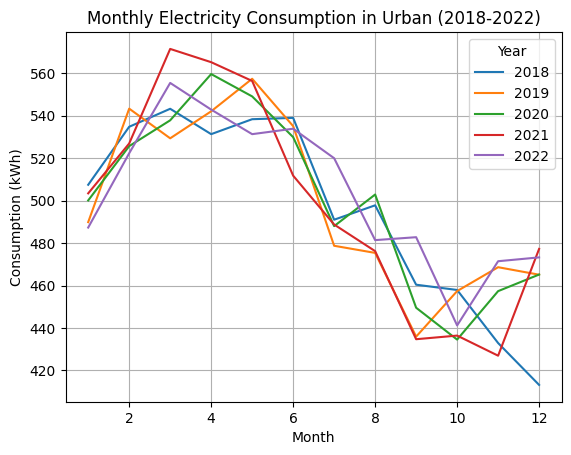

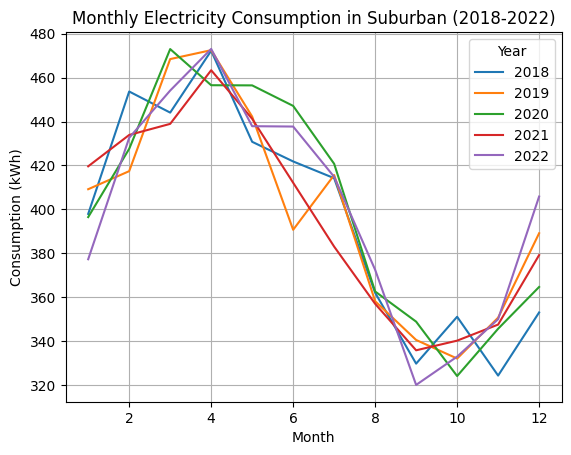

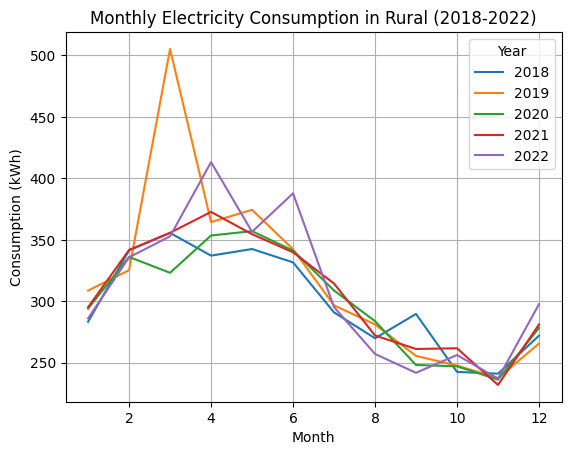

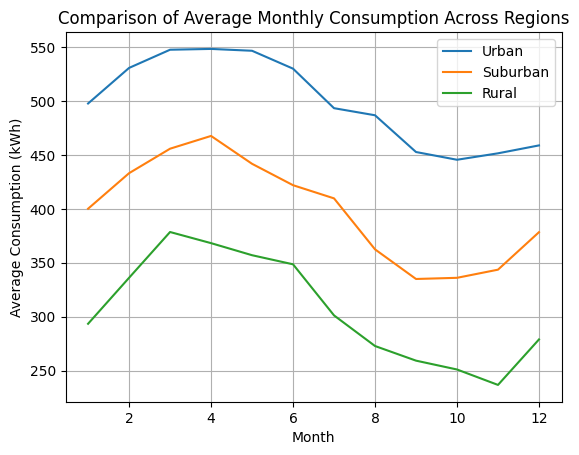

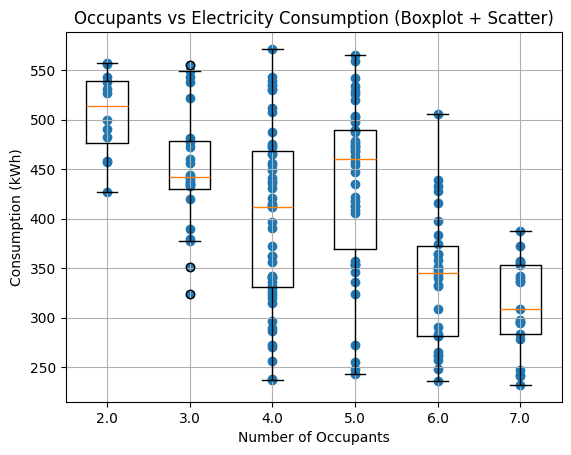

In [ ]:
# ============================================================
# TASK 3: DATA VISUALISATION
# ============================================================

print("\nTASK 3: DATA VISUALISATION")

years = sorted(df['Year'].unique()) 

for region in df["Region"].unique():
    region_data = df[df["Region"] == region]
    
    # Loop through each year to plot a separate line
    for year in years:
        year_data = region_data[region_data["Year"] == year]
        # Sort by month to ensure the line connects correctly
        year_data = year_data.sort_values("Month")
        
        plt.plot(year_data["Month"], year_data["Consumption_kWh"], label=str(year)) # Add label for the legend

    plt.title(f"Monthly Electricity Consumption in {region} (2018-2022)")
    plt.xlabel("Month")
    plt.ylabel("Consumption (kWh)")
    plt.legend(title="Year") # Show the legend
    plt.grid()
    plt.show()

# 3.2 Multi-line plot comparing regions
for region in df["Region"].unique():
    region_data = df[df["Region"] == region]
    
    # Group by Month and calculate the average (mean) consumption across all years
    avg_region_data = region_data.groupby("Month")["Consumption_kWh"].mean()

    # Plot the averaged data
    plt.plot(avg_region_data.index, avg_region_data.values, label=f"{region}")

plt.title("Comparison of Average Monthly Consumption Across Regions")
plt.xlabel("Month")
plt.ylabel("Average Consumption (kWh)")
plt.legend()
plt.grid()
plt.show()

# 3.3 Scatter plot and Boxplot together
# Prepare data for boxplot
unique_occupants = sorted(df['Occupants'].unique())
occupant_groups = []
for occupants in unique_occupants:
    occupant_groups.append(df[df['Occupants'] == occupants]['Consumption_kWh'])

# 1. Draw Boxplot with correct x positions
plt.boxplot(occupant_groups, positions=unique_occupants)

# 2. Draw Scatter plot on top
# 'alpha' makes points transparent so you can still see the boxplot structure
plt.scatter(df["Occupants"], df["Consumption_kWh"], alpha=0.5, color='orange', label='Datapoints')

plt.title("Occupants vs Electricity Consumption (Boxplot + Scatter)")
plt.xlabel("Number of Occupants")
plt.ylabel("Consumption (kWh)")
plt.grid()
plt.show()

1. A loop was implemented to generate separate line graphs for the Urban,
Suburban, and Rural regions. By plotting Month against Consumption_kWh, we can track the monthly electric consumption over the five-year period (2018–2022).

2. A multi-line plot was constructed to facilitate a direct comparison between the Urban, Suburban and Rural. This visualization highlights the disparity in energy demand across different living environments.

3. Scatter Plot (Occupants vs. Consumption) is used to visualize the relationship between the number of occupants and energy usage. By observing the density and direction of the points, we can visually confirm the correlation strength calculated in the descriptive analysis phase.

4. Occupant-wise Boxplot is used to visualize the distribution of consumption, showing the median usage, the interquartile range, and identifying any remaining potential outliers for each specific household size. It demonstrates how the variance in electricity usage changes as the number of occupants increases.





TASK 4: PREDICTIVE ANALYSIS

Model Performance:
R-squared: 0.9510
Mean Absolute Error: 4.8118


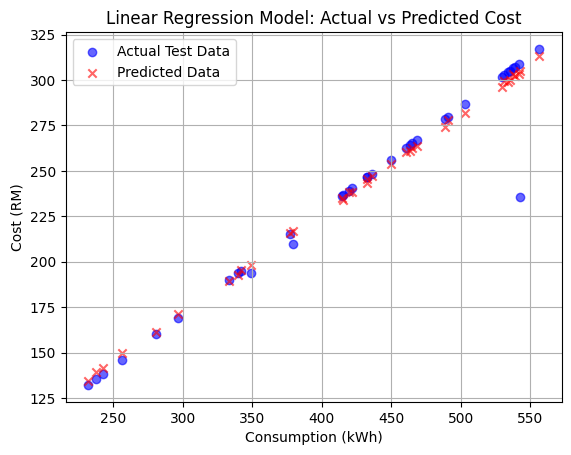

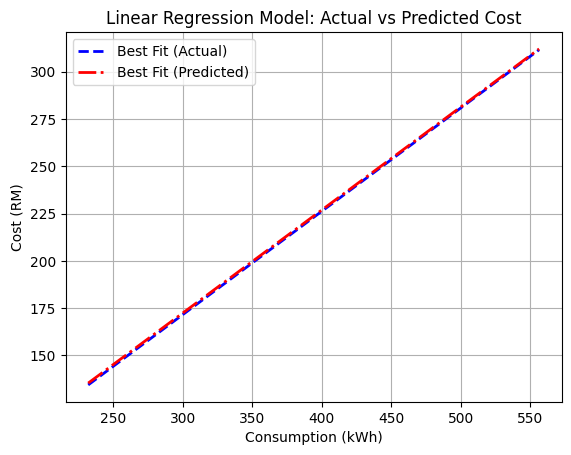

In [ ]:
# ============================================================
# TASK 4: PREDICTIVE ANALYSIS (Enhanced with NumPy)
# ============================================================

print("\nTASK 4: PREDICTIVE ANALYSIS")

X = df[['Year', 'Month', 'Region', 'Occupants']].copy()
# pd.factorize() converts categorical data (Region strings) into numeric codes (0, 1, 2, ...)
# Returns: (codes array, unique categories array)
# We only need the codes, so we use _ to ignore the unique categories
X['Region'], _ = pd.factorize(X['Region'])
y = df[['Consumption_kWh', 'Cost_RM']]

# 4.1 Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4.2 Build and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# 4.3 Predict using NumPy arrays
y_pred = model.predict(X_test)

# 4.4 Evaluate model performance
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f"\nModel Performance:")
print(f"R-squared: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")

# 4.5 Visualise Actual vs Predicted Cost

# Use index for x-axis since we're comparing predictions
# x_index creates an array of sequential numbers (0, 1, 2, ..., n-1) representing each test sample position
# This allows us to plot all predictions side-by-side for easy comparison
x_index = np.arange(len(y_test))

# Draw Lines of Best Fit
# --- Line for Actual Data ---
# np.polyfit(x, y, 1) calculates the slope (m) and intercept (c) for a degree 1 (linear) fit
m_actual, c_actual = np.polyfit(x_index, y_test['Cost_RM'], 1)
plt.plot(x_index, m_actual * x_index + c_actual, color='blue', linestyle='--', linewidth=2, label='Best Fit (Actual)')

# --- Line for Predicted Data ---
m_pred, c_pred = np.polyfit(x_index, y_pred[:, 1], 1)
plt.plot(x_index, m_pred * x_index + c_pred, color='red', linestyle='-.', linewidth=2, label='Best Fit (Predicted)')

plt.title("Linear Regression Model: Actual vs Predicted Cost")
plt.xlabel("Test Sample Index")
plt.ylabel("Cost (RM)")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# ============================================================
# EXPORT CLEANED DATASET
# ============================================================

# Convert the edited DataFrame to CSV file
df.to_csv("cleaned_dataset_student.csv", index=(False))

# Download the file
from google.colab import files
files.download("cleaned_dataset_student.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>



1. Select Consumption_kWh and Occupants as features as these are the primary drivers of electricity usage. The target variable was set as Cost_RM, which is the value the model aims to predict.
2. Using the train_test_split function, the data was divided into two subsets: 80% for training the model and 20% for testing its performance.
3. Build and train the Linear Regression Model.An algorithm was initialized and fitted to the training data (X_train and y_train).
4. Once trained, the model was used to generate predictions (y_pred) using the test features.




##**WORK DIVISION**
| TASK / ACTION | PIC |
| :---      | :----: |
| TASK 1     |  CHOO KAI WEN, KUAN JIA CHENG |
| TASK 2     |  CHOO KAI WEN, BOO KAI CHENG |
| TASK 3     |  CHOO KAI WEN, MUHAMMAD HARIZ SYUKRI BIN HASDI |
| TASK 4     |  CHOO KAI WEN, PHANG ZHENG QIAN   |  
| REPORT      | PHANG ZHENG QIAN, KUAN JIA CHENG, BOO KAI CHENG, MUHAMMAD HARIZ SYUKRI BIN HASDI  |





##**CONCLUSION**
This assignment provided a comprehensive workflow for analyzing electricity usage data using Python. By performing data cleaning, visualization, and predictive modeling, we were able to analyze the relationship between household size and electricity costs across various regions. The trend analysis and scatter plots highlighted how consumption varies by region and occupancy, while the Linear Regression model offered a practical tool for forecasting future costs. Overall, the project demonstrated the effectiveness of data science techniques in understanding and predicting real-world utility consumption patterns.


